# Text Generation with Dynamic Neural Network

This notebook demonstrates building a generative model using DynamicNetwork for next-word prediction.

## Features:
- **Bilingual**: English + Arabic text generation
- **5 Pattern Types**: Associations, Categories, Sequences, Templates, Analogies
- **100K Training Records**: 80K train / 10K val / 10K test
- **First Principles Design**: Patterns designed for BoW + softmax architecture

## 1. Setup and Imports

In [1]:
import sys
import os
import numpy as np
import time

# Add paths
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..'))
src_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

sys.path.insert(0, os.path.join(project_root, 'python'))
sys.path.insert(0, src_dir)

print(f"Project root: {project_root}")
print(f"Source dir: {src_dir}")

Project root: c:\Workspaces\dynamic_nn
Source dir: c:\Workspaces\dynamic_nn\notebooks\gen_model


In [2]:
# Import our modules
from src.data_generator import GenerativeDataGenerator, generate_dataset, get_data_statistics
from src.tokenizer import GenerativeTokenizer, normalize_features, one_hot_encode
from src.trainer import GenerativeTrainer
from src.evaluator import GenerativeEvaluator

# Import DynamicNetwork for visualization
from pydnn import DynamicNetwork
from pydnn.visualization import auto_generate_plots

print("All imports successful!")

Note: tqdm not installed. Install with 'pip install tqdm' for progress bars.
All imports successful!


## 2. Generate Training Data (100K Samples)

In [3]:
# Configuration
NUM_SAMPLES = 10000
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
SEED = 87
EN_RATIO = 0.5  # 60% English, 40% Arabic

DATA_DIR = "./"  # Save in same directory as notebook

print(f"Generating {NUM_SAMPLES:,} samples...")
print(f"  Train: {int(NUM_SAMPLES * TRAIN_RATIO):,}")
print(f"  Val:   {int(NUM_SAMPLES * VAL_RATIO):,}")
print(f"  Test:  {int(NUM_SAMPLES * (1 - TRAIN_RATIO - VAL_RATIO)):,}")

Generating 10,000 samples...
  Train: 8,000
  Val:   1,000
  Test:  999


In [4]:
# Generate dataset
start_time = time.time()

train_file, val_file, test_file = generate_dataset(
    num_samples=NUM_SAMPLES,
    output_dir=DATA_DIR,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    en_ratio=EN_RATIO
)

elapsed = time.time() - start_time
print(f"\nData generation completed in {elapsed:.2f}s")

Generating 10,000 samples...
Generated 10,000 samples
Training samples: 8,000 -> ./train.csv
Validation samples: 1,000 -> ./val.csv
Test samples: 1,000 -> ./test.csv

Data generation completed in 0.07s


## 3. Load and Explore Data

In [5]:
# Load data
generator = GenerativeDataGenerator(seed=SEED)

train_inputs, train_outputs, train_patterns, train_langs = generator.load_from_csv(train_file)
val_inputs, val_outputs, val_patterns, val_langs = generator.load_from_csv(val_file)
test_inputs, test_outputs, test_patterns, test_langs = generator.load_from_csv(test_file)

print(f"Loaded data:")
print(f"  Train: {len(train_inputs):,} samples")
print(f"  Val:   {len(val_inputs):,} samples")
print(f"  Test:  {len(test_inputs):,} samples")

Loaded data:
  Train: 8,000 samples
  Val:   1,000 samples
  Test:  1,000 samples


In [6]:
# Data statistics
stats = get_data_statistics(train_inputs, train_outputs, train_patterns, train_langs)

print("\nTraining Data Statistics:")
print(f"  Total samples: {stats['total_samples']:,}")
print(f"  Unique inputs: {stats['unique_inputs']:,}")
print(f"  Unique outputs: {stats['unique_outputs']:,}")
print(f"  Avg input words: {stats['avg_input_words']:.2f}")

print("\nPattern Distribution:")
for pattern, count in sorted(stats['pattern_distribution'].items()):
    pct = count / stats['total_samples'] * 100
    print(f"  {pattern:15s}: {count:,} ({pct:.1f}%)")

print("\nLanguage Distribution:")
for lang, count in sorted(stats['language_distribution'].items()):
    pct = count / stats['total_samples'] * 100
    print(f"  {lang:15s}: {count:,} ({pct:.1f}%)")


Training Data Statistics:
  Total samples: 8,000
  Unique inputs: 1,645
  Unique outputs: 350
  Avg input words: 3.11

Pattern Distribution:
  analogy        : 1,626 (20.3%)
  association    : 1,574 (19.7%)
  category       : 1,590 (19.9%)
  sequence       : 1,596 (20.0%)
  template       : 1,614 (20.2%)

Language Distribution:
  ar             : 4,013 (50.2%)
  en             : 3,987 (49.8%)


In [7]:
# Show sample data for each pattern type
print("\nSample Data by Pattern Type:")
print("=" * 70)

shown_patterns = set()
for i in range(len(train_inputs)):
    pattern = train_patterns[i]
    if pattern not in shown_patterns:
        print(f"\n{pattern.upper()}:")
        # Show 2 examples per pattern (1 EN, 1 AR if available)
        count = 0
        for j in range(i, min(i + 100, len(train_inputs))):
            if train_patterns[j] == pattern:
                print(f"  [{train_langs[j]}] '{train_inputs[j]}' -> '{train_outputs[j]}'")
                count += 1
                if count >= 4:
                    break
        shown_patterns.add(pattern)
    if len(shown_patterns) >= 5:
        break


Sample Data by Pattern Type:

TEMPLATE:
  [en] 'the big dog is' -> 'strong'
  [ar] 'الشمس الحار هو' -> 'ساطعة'
  [en] 'the slow progress is' -> 'steady'
  [ar] 'الشمس الحار هو' -> 'ساطعة'

CATEGORY:
  [en] 'body eye ear finger head' -> 'arm'
  [en] 'animal elephant dog' -> 'sheep'
  [en] 'food egg meat fish rice' -> 'milk'
  [ar] 'لون اسود بني بنفسجي' -> 'وردي'

ANALOGY:
  [ar] 'حصان مهر بقرة' -> 'عجل'
  [en] 'cow calf horse' -> 'foal'
  [ar] 'اخت انثى ذكر' -> 'اخ'
  [en] 'bird chick fish' -> 'fry'

SEQUENCE:
  [ar] 'ثالث رابع خامس' -> 'سادس'
  [en] 'eight nine ten' -> 'eleven'
  [en] 'four six eight' -> 'ten'
  [en] 'sixth seventh eighth' -> 'ninth'

ASSOCIATION:
  [en] 'wild animal' -> 'lion'
  [ar] 'حيوان مزرعة' -> 'خنزير'
  [en] 'color brown' -> 'coffee'
  [en] 'wild animal' -> 'elephant'


## 4. Tokenization

In [8]:
# Build tokenizer
tokenizer = GenerativeTokenizer(max_vocab_size=1000)

print("Building vocabularies...")
tokenizer.fit(train_inputs, train_outputs, verbose=True)

Building vocabularies...
  Building vocabularies from 8,000 samples...
  Vocabularies built in 0.02s
  Input vocabulary size: 434
  Output vocabulary size: 350
  Unique input words: 433


In [9]:
# Tokenizer summary
vocab_summary = tokenizer.get_vocab_summary(top_n=15)

print("\nVocabulary Summary:")
print(f"  Input vocab size:  {vocab_summary['input_vocab_size']:,}")
print(f"  Output vocab size: {vocab_summary['output_vocab_size']:,}")

print("\nTop Input Words:")
for word, count in vocab_summary['top_input_words'][:10]:
    print(f"  {word:20s}: {count:,}")

print("\nSample Output Mappings:")
for word, idx in list(vocab_summary['sample_output_mappings'])[:10]:
    print(f"  {word:20s} -> {idx}")


Vocabulary Summary:
  Input vocab size:  434
  Output vocab size: 350

Top Input Words:
  the                 : 811
  is                  : 811
  هو                  : 803
  لون                 : 647
  color               : 602
  حيوان               : 382
  animal              : 375
  six                 : 296
  eight               : 291
  five                : 284

Sample Output Mappings:
  amethyst             -> 0
  annoying             -> 1
  apple                -> 2
  arm                  -> 3
  aunt                 -> 4
  autumn               -> 5
  banana               -> 6
  bat                  -> 7
  bear                 -> 8
  bee                  -> 9


In [10]:
# Transform data
print("\nTransforming training data...")
X_train = tokenizer.transform_input(train_inputs, verbose=True)
y_train_idx = tokenizer.transform_output(train_outputs, verbose=True)

print("\nTransforming validation data...")
X_val = tokenizer.transform_input(val_inputs, verbose=False)
y_val_idx = tokenizer.transform_output(val_outputs, verbose=False)

print("\nTransforming test data...")
X_test = tokenizer.transform_input(test_inputs, verbose=False)
y_test_idx = tokenizer.transform_output(test_outputs, verbose=False)


Transforming training data...
  Converting 8,000 texts to bag-of-words...
  Conversion completed in 0.03s
  Feature matrix shape: (8000, 434)
  Feature matrix size: 13.2 MB
  Converting 8,000 output words to indices...
  Output indices shape: (8000,)

Transforming validation data...

Transforming test data...


In [11]:
# Normalize features
X_train = normalize_features(X_train)
X_val = normalize_features(X_val)
X_test = normalize_features(X_test)

# One-hot encode outputs
num_classes = tokenizer.output_vocab_size
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)
y_test = one_hot_encode(y_test_idx, num_classes)

print(f"\nFinal Data Shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")


Final Data Shapes:
  X_train: (8000, 434)
  y_train: (8000, 350)
  X_val:   (1000, 434)
  y_val:   (1000, 350)
  X_test:  (1000, 434)
  y_test:  (1000, 350)


## 5. Training

In [12]:
# Create trainer
trainer = GenerativeTrainer(
    input_vocab_size=tokenizer.input_vocab_size,
    output_vocab_size=tokenizer.output_vocab_size,
    seed=SEED,
    cost_function="CrossEntropy"
)

# Set tokenizer for inference
trainer.set_tokenizer(tokenizer)

print(f"Trainer configured:")
print(f"  Input vocab:  {trainer.input_vocab_size}")
print(f"  Output vocab: {trainer.output_vocab_size}")
print(f"  Cost function: {trainer.cost_function}")

Trainer configured:
  Input vocab:  434
  Output vocab: 350
  Cost function: CrossEntropy


In [13]:
# Build network
network = trainer.build_network()

print(f"\nNetwork built:")
print(f"  Input shape: {network.input_shape}")
print(f"  Output size: {network.output_size}")

Note: Using pure Python fallback. For best performance, build C++ extensions.

Network built:
  Input shape: (434,)
  Output size: 350


In [14]:
# Train!
print("\n" + "=" * 50)
print("TRAINING")
print("=" * 50)

metrics = trainer.train(X_train, y_train, verbose=True)

print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"  Epochs:          {metrics.epochs_completed}")
print(f"  Final cost:      {metrics.final_cost:.4f}")
print(f"  Best cost:       {metrics.best_cost:.4f}")
print(f"  Training time:   {metrics.training_time_ms / 1000:.2f}s")
print(f"  Samples/second:  {metrics.samples_per_second:,.0f}")


TRAINING

Training on 8,000 samples...
  Input shape: (8000, 434)
  Output shape: (8000, 350)
Training Dynamic Neural Network
  Input shape: (434,)
  Output size: 350
  Seed: 87
  Cost function: CrossEntropy
  Samples: 8000


PHASE 1: EXPLORATION (10 epochs)
  Epoch 0: cost=4.8941, layers=2, nodes=358
  Epoch 2: cost=4.5008, layers=2, nodes=358
  Epoch 4: cost=3.5348, layers=2, nodes=358
  Epoch 6: cost=2.7946, layers=2, nodes=358
  Epoch 8: cost=2.2988, layers=2, nodes=358

PHASE 2: ESTIMATION (10 epochs)
  Estimated epochs for 90% efficiency: 133

PHASE 3: MAIN TRAINING (133 epochs)
  Epoch 0: cost=1.7157, eff=53.62%, sat_th=0.62
  Epoch 10: cost=1.4150, eff=66.73%, sat_th=0.65
  Epoch 20: cost=1.2109, eff=63.00%, sat_th=0.65
  Epoch 30: cost=1.0834, eff=55.29%, sat_th=0.59
  Epoch 40: cost=1.0366, eff=55.64%, sat_th=0.56
  Epoch 50: cost=0.9992, eff=53.77%, sat_th=0.56
  Epoch 60: cost=0.9734, eff=51.74%, sat_th=0.56
  Epoch 70: cost=0.9622, eff=49.52%, sat_th=0.56
  Epoch 80: cost

In [15]:
# Network health
health = trainer.get_health_status()

print("\nNetwork Health:")
print(f"  State:           {health['state']}")
print(f"  Overall health:  {health['overall_health']:.2%}")
print(f"  Cancer score:    {health['cancer_score']:.2%}")
print(f"  Alzheimer score: {health['alzheimer_score']:.2%}")
print(f"  Layers:          {health['current_layers']}")
print(f"  Nodes:           {health['current_nodes']}")
print(f"  Diagnosis:       {health['diagnosis']}")


Network Health:
  State:           Healthy
  Overall health:  100.00%
  Cancer score:    0.00%
  Alzheimer score: 0.00%
  Layers:          2
  Nodes:           358
  Diagnosis:       Network is healthy


## 6. Evaluation

In [16]:
# Create evaluator
evaluator = GenerativeEvaluator(trainer, tokenizer)

In [17]:
# Evaluate on test set
results = evaluator.evaluate(
    test_inputs,
    test_outputs,
    pattern_types=test_patterns,
    languages=test_langs,
    verbose=True
)


Evaluating on 1,000 samples...

EVALUATION RESULTS

Overall Metrics:
  Total Samples:    1,000
  Exact Accuracy:   64.70%
  Top-3 Accuracy:   77.80%
  Top-5 Accuracy:   89.80%
  Perplexity:       2.96

Per-Pattern Accuracy:
  analogy        : 100.00% (178/178)
  association    : 18.06% (39/216)
  category       : 12.87% (26/202)
  sequence       : 100.00% (202/202)
  template       : 100.00% (202/202)

Per-Language Accuracy:
  ar             : 66.26% (326/492)
  en             : 63.19% (321/508)


In [18]:
# Show correct predictions
print("\nCorrect Predictions:")
evaluator.show_examples(
    test_inputs[:500],
    test_outputs[:500],
    pattern_types=test_patterns[:500],
    n_examples=10,
    show_errors_only=False
)


Correct Predictions:

PREDICTION EXAMPLES

[OK] Pattern: analogy
  Input:      'uncle man woman'
  Expected:   'aunt'
  Predicted:  'aunt' (92.57%)
  Top-3:      aunt (92.57%), father (3.34%), wife (1.12%)

[OK] Pattern: template
  Input:      'السيارة الكبير هو'
  Expected:   'سريعة'
  Predicted:  'سريعة' (98.45%)
  Top-3:      سريعة (98.45%), قوي (0.61%), بطيئة (0.35%)

[XX] Pattern: category
  Input:      'مركبة سيارة قارب طائرة دراجة'
  Expected:   'حافلة'
  Predicted:  'قطار' (24.77%)
  Top-3:      قطار (24.77%), حافلة (20.31%), سيارة (12.94%)

[XX] Pattern: category
  Input:      'food bread egg meat'
  Expected:   'pasta'
  Predicted:  'fish' (17.95%)
  Top-3:      fish (17.95%), milk (13.65%), soup (10.65%)

[OK] Pattern: template
  Input:      'the big house is'
  Expected:   'old'
  Predicted:  'old' (94.67%)
  Top-3:      old (94.67%), tall (2.39%), fast (1.76%)

[XX] Pattern: association
  Input:      'sea animal'
  Expected:   'whale'
  Predicted:  'fish' (22.75%)
  Top-3

In [19]:
# Show errors
print("\nIncorrect Predictions (Errors):")
evaluator.show_examples(
    test_inputs,
    test_outputs,
    pattern_types=test_patterns,
    n_examples=10,
    show_errors_only=True
)


Incorrect Predictions (Errors):

PREDICTION EXAMPLES

[XX] Pattern: category
  Input:      'مركبة سيارة قارب طائرة دراجة'
  Expected:   'حافلة'
  Predicted:  'قطار' (24.77%)
  Top-3:      قطار (24.77%), حافلة (20.31%), سيارة (12.94%)

[XX] Pattern: category
  Input:      'food bread egg meat'
  Expected:   'pasta'
  Predicted:  'fish' (17.95%)
  Top-3:      fish (17.95%), milk (13.65%), soup (10.65%)

[XX] Pattern: association
  Input:      'sea animal'
  Expected:   'whale'
  Predicted:  'fish' (22.75%)
  Top-3:      fish (22.75%), dolphin (22.24%), whale (19.06%)

[XX] Pattern: category
  Input:      'weather fog thunder storm'
  Expected:   'wind'
  Predicted:  'snow' (22.00%)
  Top-3:      snow (22.00%), sun (19.81%), cloud (9.83%)

[XX] Pattern: association
  Input:      'حيوان بري'
  Expected:   'ذئب'
  Predicted:  'نمر' (25.57%)
  Top-3:      نمر (25.57%), اسد (24.84%), دب (21.14%)

[XX] Pattern: category
  Input:      'food milk salad soup bread'
  Expected:   'cheese'
  Predi

## 7. Generation Demo

In [20]:
# Interactive generation demo
evaluator.generation_demo(temperature=1.0)


GENERATION DEMO

  Context:    'color red'
  Generated:  'fire' (27.28%)
  Top-3:      fire (27%), strawberry (21%), cherry (19%)

  Context:    'color blue'
  Generated:  'water' (23.26%)
  Top-3:      water (23%), sky (13%), blueberry (12%)

  Context:    'one two three'
  Generated:  'four' (85.09%)
  Top-3:      four (85%), five (8%), eight (2%)

  Context:    'first second third'
  Generated:  'fourth' (92.20%)
  Top-3:      fourth (92%), fifth (3%), piglet (1%)

  Context:    'fruit apple banana'
  Generated:  'peach' (12.73%)
  Top-3:      peach (13%), banana (12%), pear (12%)

  Context:    'animal cat dog'
  Generated:  'elephant' (37.15%)
  Top-3:      elephant (37%), lion (35%), tiger (9%)

  Context:    'the big house is'
  Generated:  'old' (94.67%)
  Top-3:      old (95%), tall (2%), fast (2%)

  Context:    'king man woman'
  Generated:  'queen' (81.64%)
  Top-3:      queen (82%), father (4%), wife (4%)

  Context:    'لون احمر'
  Generated:  'تفاحة' (11.56%)
  Top-3:  

In [21]:
# Custom generation examples
custom_contexts = [
    # Test associations
    "color green",
    "color black",
    "pet animal",
    
    # Test sequences
    "four five six",
    "second third fourth",
    
    # Test categories
    "fruit grape mango",
    "animal lion tiger",
    
    # Test analogies
    "hot fire ice",
    "big elephant mouse",
    
    # Arabic tests
    "لون اخضر",
    "اربعة خمسة ستة",
    "حيوان اسد نمر",
]

print("\nCustom Generation Tests:")
print("=" * 60)

for context in custom_contexts:
    word, confidence = trainer.generate_next_word(context)
    print(f"  '{context}' -> '{word}' ({confidence:.2%})")


Custom Generation Tests:
  'color green' -> 'leaf' (27.17%)
  'color black' -> 'crow' (21.42%)
  'pet animal' -> 'fish' (34.91%)
  'four five six' -> 'seven' (84.09%)
  'second third fourth' -> 'fifth' (94.55%)
  'fruit grape mango' -> 'peach' (12.47%)
  'animal lion tiger' -> 'cat' (18.93%)
  'hot fire ice' -> 'cold' (97.05%)
  'big elephant mouse' -> 'small' (96.89%)
  'لون اخضر' -> 'خيار' (15.27%)
  'اربعة خمسة ستة' -> 'سبعة' (90.69%)
  'حيوان اسد نمر' -> 'سمكة' (16.28%)


In [22]:
# Multi-word generation
print("\nMulti-Word Generation:")
print("=" * 60)

seed_texts = [
    "one two",
    "color",
    "fruit apple",
]

for seed in seed_texts:
    sequence = trainer.generate_sequence(seed, num_words=3, temperature=0.8)
    generated_words = [w for w, c in sequence]
    print(f"\n  Seed: '{seed}'")
    print(f"  Generated: {' -> '.join(generated_words)}")
    for word, conf in sequence:
        print(f"    {word}: {conf:.2%}")


Multi-Word Generation:

  Seed: 'one two'
  Generated: four -> five -> seven
    four: 81.49%
    five: 38.19%
    seven: 91.89%

  Seed: 'color'
  Generated: banana
    banana: 7.37%

  Seed: 'fruit apple'
  Generated: banana -> peach -> grape
    banana: 17.02%
    peach: 15.05%
    grape: 13.31%


## 8. Save Model

In [23]:
# Save trained model
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

trainer.save(MODEL_DIR, "generative_model")
print(f"Model saved to {MODEL_DIR}/generative_model.json")

Model saved to ./models/generative_model.json


In [24]:
# Verify model can be loaded
loaded_trainer = GenerativeTrainer.load(os.path.join(MODEL_DIR, "generative_model.json"))
loaded_trainer.set_tokenizer(tokenizer)

# Test loaded model
test_word, test_conf = loaded_trainer.generate_next_word("color red")
print(f"Loaded model test: 'color red' -> '{test_word}' ({test_conf:.2%})")

Note: Using pure Python fallback. For best performance, build C++ extensions.
Loaded model test: 'color red' -> 'fire' (27.28%)


## 9. Visualization

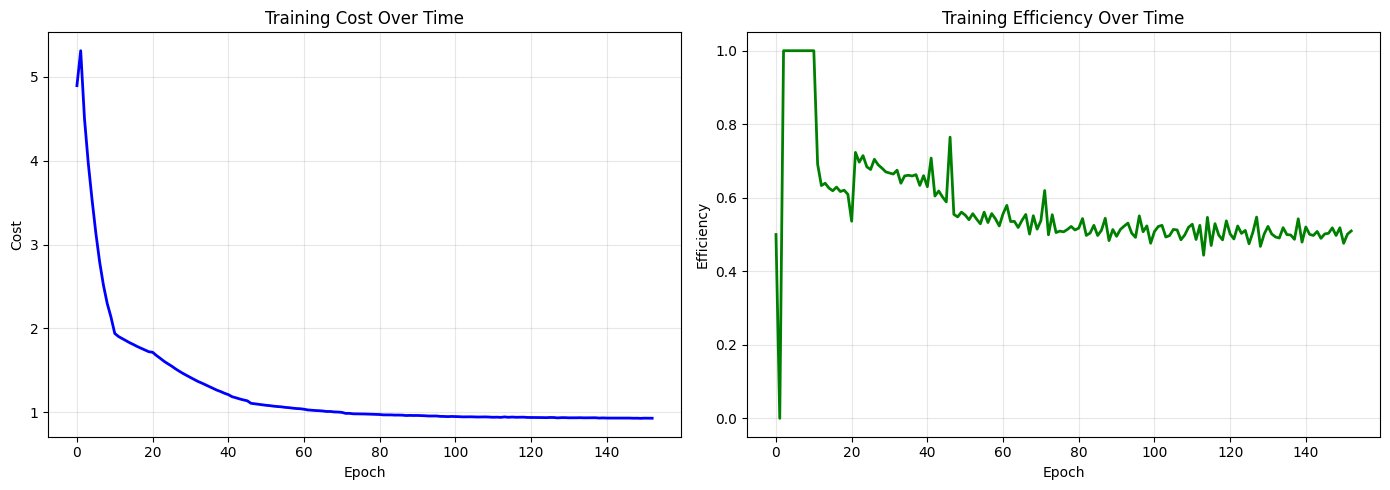

Saved training_history.png


In [25]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost history
axes[0].plot(metrics.cost_history, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cost')
axes[0].set_title('Training Cost Over Time')
axes[0].grid(True, alpha=0.3)

# Efficiency history
axes[1].plot(metrics.efficiency_history, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Efficiency')
axes[1].set_title('Training Efficiency Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved training_history.png")

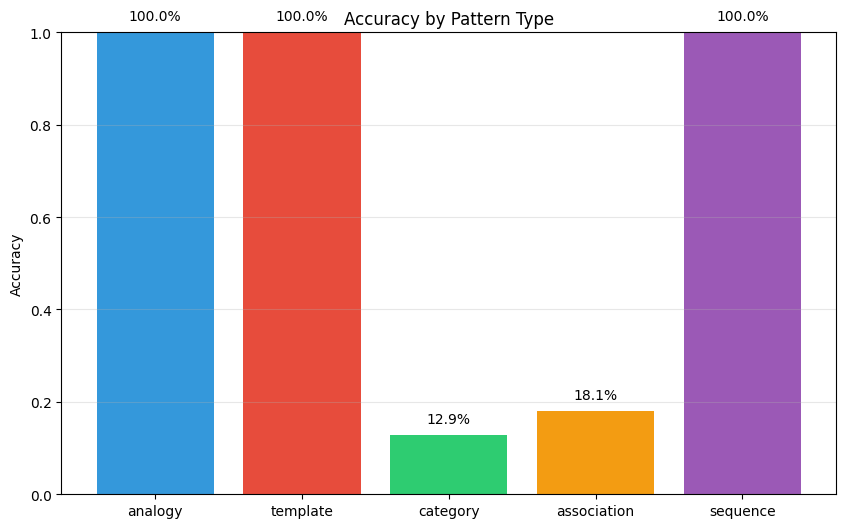

Saved pattern_accuracy.png


In [26]:
# Per-pattern accuracy visualization
if 'per_pattern' in results:
    patterns = list(results['per_pattern'].keys())
    accuracies = [results['per_pattern'][p]['accuracy'] for p in patterns]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(patterns, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
    plt.ylabel('Accuracy')
    plt.title('Accuracy by Pattern Type')
    plt.ylim(0, 1)
    
    # Add value labels
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{acc:.1%}', ha='center', va='bottom', fontsize=10)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.savefig('./pattern_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved pattern_accuracy.png")

## 10. Summary

In [27]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  Total samples:     {NUM_SAMPLES:,}")
print(f"  Training samples:  {len(train_inputs):,}")
print(f"  Validation samples: {len(val_inputs):,}")
print(f"  Test samples:      {len(test_inputs):,}")

print(f"\nModel:")
print(f"  Input vocab size:  {tokenizer.input_vocab_size:,}")
print(f"  Output vocab size: {tokenizer.output_vocab_size:,}")
print(f"  Network layers:    {health['current_layers']}")
print(f"  Network nodes:     {health['current_nodes']}")

print(f"\nTraining:")
print(f"  Epochs:            {metrics.epochs_completed}")
print(f"  Training time:     {metrics.training_time_ms / 1000:.2f}s")
print(f"  Final cost:        {metrics.final_cost:.4f}")

print(f"\nTest Performance:")
print(f"  Exact accuracy:    {results['exact_accuracy']:.2%}")
print(f"  Top-3 accuracy:    {results['top3_accuracy']:.2%}")
print(f"  Top-5 accuracy:    {results['top5_accuracy']:.2%}")
print(f"  Perplexity:        {results['perplexity']:.2f}")

print("\n" + "=" * 60)


TRAINING SUMMARY

Dataset:
  Total samples:     10,000
  Training samples:  8,000
  Validation samples: 1,000
  Test samples:      1,000

Model:
  Input vocab size:  434
  Output vocab size: 350
  Network layers:    2
  Network nodes:     358

Training:
  Epochs:            153
  Training time:     21.24s
  Final cost:        0.9292

Test Performance:
  Exact accuracy:    64.70%
  Top-3 accuracy:    77.80%
  Top-5 accuracy:    89.80%
  Perplexity:        2.96

